In [6]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

In [7]:
# ==================== Configuration ====================
class Config_MLP:
    """Configuration class for model hyperparameters"""
    # Network architecture
    hidden_layers = [32, 16, 8]

    # Training parameters
    learning_rate = 0.001
    batch_size = 1024
    epochs = 100
    early_stopping_rounds = 10
    n_ensembles = 10

    # Data parameters
    initial_train_years = 3
    validation_years = 1
    test_months = 1

    # Lag candidates
    lag_candidates = [1, 5, 16, 22, 32, 44, 66, 88]

    # Transformation parameters
    use_log_transform = True  # Model log(RV) instead of RV directly
    target_scaler = True  # Scale target variable

    # Device
    #if torch.backends.mps.is_available(): #mps sucks...
        #device = torch.device("mps")
       # print("Using MPS")
    #if torch.cuda.is_available():
        #device = torch.device('cuda')
        #print("Using CUDA")
    #else:
    device = torch.device('cpu')
    print("Using CPU")


Using CPU


In [8]:
# ==================== Configuration ====================
class Config_LSTM:
    """Configuration class for model hyperparameters"""
    # Network architecture
    hidden_layers = [32, 16]

    # Training parameters
    learning_rate = 0.001
    batch_size = 1024
    epochs = 100
    early_stopping_rounds = 10
    n_ensembles = 10

    # Data parameters
    initial_train_years = 3
    validation_years = 1
    test_months = 1

    # Lag candidates
    lag_candidates = [1, 5, 16, 22, 32, 44, 66, 88]

    # Transformation parameters
    use_log_transform = True  # Model log(RV) instead of RV directly
    target_scaler = True  # Scale target variable

    # Device
    if torch.cuda.is_available(): #default to cuda for lstm though
        device = torch.device('cuda')
        print("Using CUDA")
    elif torch.backends.mps.is_available(): #haven't tried mps on lstm
        device = torch.device("mps")
        print("Using MPS")
    else:
        device = torch.device('cpu')
        print("Using CPU")


Using CUDA


In [9]:
class MLPWithBatchNorm(nn.Module):
    """MLP with Batch Normalization - no activation on output"""
    def __init__(self, input_dim, hidden_layers):
        super(MLPWithBatchNorm, self).__init__()

        layers = []
        prev_dim = input_dim

        # Build hidden layers with batch normalization
        for hidden_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.2))
            prev_dim = hidden_dim

        # Output layer - NO activation
        layers.append(nn.Linear(prev_dim, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Direct output, no activation
        # The log transform + exp inverse will ensure positivity
        return self.network(x)

In [10]:
class LSTMWithBatchNorm(nn.Module):
    """
    Expected input from the current pipeline is a 2D tensor of shape (batch, num_lags).
    This module reshapes it to (batch, seq_len=num_lags, input_size=1) for the LSTM.

    hidden_layers:
        - hidden_layers[0] is used as the LSTM hidden size for the first layer.
        - If hidden_layers has length >= 2, an additional LSTM layer is stacked with
          hidden size hidden_layers[1].
        - After the LSTM stack, we take the last time step's output, apply BatchNorm1d,
          and map to a single output with a Linear layer.
    """
    def __init__(self, input_dim: int, hidden_layers, dropout: float = 0.0):
        super().__init__()
        if not isinstance(hidden_layers, (list, tuple)) or len(hidden_layers) == 0:
            raise ValueError("hidden_layers must be a non-empty list/tuple, e.g., [32] or [32, 16].")

        self.input_dim = int(input_dim)  # number of lags (sequence length)
        self.hidden_layers = list(hidden_layers)
        self.dropout = float(dropout)

        # Build LSTM stack
        self.lstm_layers = nn.ModuleList()
        # First LSTM layer: input_size=1 (lag value), hidden_size=hidden_layers[0]
        self.lstm_layers.append(nn.LSTM(
            input_size=1,
            hidden_size=self.hidden_layers[0],
            num_layers=1,
            batch_first=True
        ))

        # Additional LSTM layers if provided
        for in_size, out_size in zip(self.hidden_layers[:-1], self.hidden_layers[1:]):
            self.lstm_layers.append(nn.LSTM(
                input_size=in_size,
                hidden_size=out_size,
                num_layers=1,
                batch_first=True
            ))

        # Optional dropout
        self.use_dropout = self.dropout > 0.0
        if self.use_dropout:
            self.dropout_layer = nn.Dropout(self.dropout)

        # BatchNorm over the final hidden size
        last_hidden = self.hidden_layers[-1]
        self.bn = nn.BatchNorm1d(last_hidden)

        # Final linear to 1-d output
        self.fc_out = nn.Linear(last_hidden, 1)

        # Initialize the output layer (optional but helps stability)
        nn.init.kaiming_uniform_(self.fc_out.weight, a=np.sqrt(5))
        if self.fc_out.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.fc_out.weight)
            bound = 1 / np.sqrt(fan_in)
            nn.init.uniform_(self.fc_out.bias, -bound, bound)

    def forward(self, x):
        """
        Accepts x of shape:
          - (batch, num_lags)  -> will be reshaped to (batch, seq_len=num_lags, 1), or
          - (batch, seq_len, input_size)
        Returns:
          - (batch, 1)
        """
        if x.dim() == 2:
            # (N, num_lags) -> (N, seq_len=num_lags, 1)
            x = x.unsqueeze(-1)
        elif x.dim() == 3:
            # already (batch, seq_len, input_size)
            pass
        else:
            raise ValueError(f"Expected input of shape (N, L) or (N, L, C), got {tuple(x.shape)}")

        # Pass through LSTM stack
        for lstm in self.lstm_layers:
            x, _ = lstm(x)  # x: (batch, seq_len, hidden_size)

        # Last time step
        last = x[:, -1, :]  # (batch, hidden_size)

        # BatchNorm + optional dropout
        last = self.bn(last)
        if self.use_dropout:
            last = self.dropout_layer(last)

        out = self.fc_out(last)  # (batch, 1)
        return out


In [11]:
# ==================== Data Preparation Functions ====================
def load_and_prepare_data(filepath='SPY.csv'):
    """Load and prepare the realized volatility data"""
    rv = pd.read_csv(filepath)
    rv = rv[["Date", "Volatility", "Type"]]
    rv.rename(columns={"Volatility": "RV_daily"}, inplace=True)
    rv = rv[rv['Type'] == 'QMLE-Trade']
    rv.drop(columns=['Type'], inplace=True)
    rv = rv.set_index("Date")
    rv.index = pd.to_datetime(rv.index)
    rv.index.name = "date"

    print(f"Data loaded: {len(rv)} observations")
    print(f"Date range: {rv.index.min()} to {rv.index.max()}")

    return rv

def create_lagged_features(data, lags):
    """Create lagged features for the model"""
    df = data.copy()

    # Create lagged features
    for lag in lags:
        df[f'lag_{lag}'] = df['RV_daily'].shift(lag)

    # Remove rows with NaN values (from lagging)
    df = df.dropna()

    return df

def prepare_train_val_test_data(df, train_start, train_end, val_end, test_end):
    """Split data into train, validation, and test sets"""
    train_data = df[train_start:train_end]
    val_data = df[train_end:val_end]
    test_data = df[val_end:test_end]

    return train_data, val_data, test_data

In [12]:
# ==================== Model Training Functions ====================
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=10, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.early_stop = False

    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

def train_single_model(X_train, y_train, X_val, y_val, config, verbose=False):
    """Train a single MLP model"""
    # Convert to tensors
    X_train_tensor = torch.FloatTensor(X_train).to(config.device)
    y_train_tensor = torch.FloatTensor(y_train).to(config.device)
    X_val_tensor = torch.FloatTensor(X_val).to(config.device)
    y_val_tensor = torch.FloatTensor(y_val).to(config.device)

    # Create data loaders
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)

    # Initialize model
    model_cls = LSTMWithBatchNorm if isinstance(config, Config_LSTM) else MLPWithBatchNorm
    model = model_cls(X_train.shape[1], config.hidden_layers).to(config.device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=config.learning_rate)

    # Early stopping
    early_stopping = EarlyStopping(patience=config.early_stopping_rounds)

    # Training loop
    train_losses = []
    val_losses = []

    for epoch in range(config.epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()

        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation phase
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val_tensor)
            val_loss = criterion(val_outputs, y_val_tensor).item()
            val_losses.append(val_loss)

        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            if verbose:
                print(f"Early stopping triggered at epoch {epoch+1}")
            break

        if verbose and (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{config.epochs}, Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}")

    return model, train_losses, val_losses

def train_ensemble(X_train, y_train, X_val, y_val, config):
    """Train an ensemble of models"""
    models = []

    print(f"Training ensemble of {config.n_ensembles} models...")
    for i in range(config.n_ensembles):
        print(f"Training model {i+1}/{config.n_ensembles}")
        model, _, _ = train_single_model(X_train, y_train, X_val, y_val, config, verbose=False)
        models.append(model)

    return models

def predict_ensemble(models, X, config):
    """Make predictions using ensemble of models"""
    X_tensor = torch.FloatTensor(X).to(config.device)
    predictions = []

    for model in models:
        model.eval()
        with torch.no_grad():
            pred = model(X_tensor).cpu().numpy()
            predictions.append(pred)

    # Average predictions
    ensemble_pred = np.mean(predictions, axis=0)
    return ensemble_pred

In [13]:
# ==================== Evaluation Functions ====================
def calculate_mse(y_true, y_pred):
    """Calculate Mean Squared Error"""
    return mean_squared_error(y_true, y_pred)

def calculate_qlike(y_true, y_pred):
    """Calculate QLIKE loss with better numerical stability"""
    # Ensure positive values with larger epsilon for stability
    y_true = np.maximum(y_true, 1e-6)
    y_pred = np.maximum(y_pred, 1e-6)

    # QLIKE formula
    qlike = np.mean(y_true / y_pred - np.log(y_true / y_pred) - 1)

    # Cap extreme values (sanity check)
    if np.isnan(qlike) or np.isinf(qlike) or qlike > 1000:
        print(f"Warning: Extreme QLIKE value detected: {qlike}")
        return 1000.0  # Cap at 1000

    return qlike

In [14]:
# Calculate Information Criteria

#def calculate_BIC():


In [15]:
# ==================== Expanding Window Implementation ====================
def expanding_window_forecast(rv_data, config):
    """Implement expanding window forecasting with proper transformations"""
    # Create lagged features
    df_with_lags = create_lagged_features(rv_data, config.lag_candidates)

    # Initialize results storage
    all_results = []

    # Get feature columns
    feature_cols = [col for col in df_with_lags.columns if col.startswith('lag_')]

    # Start date for expanding window
    start_date = df_with_lags.index[0]
    initial_train_end = start_date + pd.DateOffset(years=config.initial_train_years)

    # Find the first valid test start date
    current_test_start = initial_train_end + pd.DateOffset(years=config.validation_years)

    print(f"\nStarting expanding window forecasting...")
    print(f"Initial training period: {start_date.date()} to {initial_train_end.date()}")
    print(f"Using log transformation: {config.use_log_transform}")
    print(f"Using target scaling: {config.target_scaler}")

    window_count = 0

    while current_test_start < df_with_lags.index[-1]:
        window_count += 1

        # Define periods
        train_end = current_test_start - pd.DateOffset(years=config.validation_years)
        val_start = train_end
        val_end = current_test_start
        test_end = min(current_test_start + pd.DateOffset(months=config.test_months),
                       df_with_lags.index[-1])

        # Get data splits
        train_data = df_with_lags[start_date:train_end]
        val_data = df_with_lags[val_start:val_end]
        test_data = df_with_lags[val_end:test_end]

        if len(test_data) == 0:
            break

        print(f"\n--- Window {window_count} ---")
        print(f"Train: {start_date.date()} to {train_end.date()} ({len(train_data)} obs)")
        print(f"Val: {val_start.date()} to {val_end.date()} ({len(val_data)} obs)")
        print(f"Test: {val_end.date()} to {test_end.date()} ({len(test_data)} obs)")

        # Prepare features
        X_train = train_data[feature_cols].values
        X_val = val_data[feature_cols].values
        X_test = test_data[feature_cols].values

        # Prepare targets with optional log transformation
        y_train_original = train_data['RV_daily'].values.reshape(-1, 1)
        y_val_original = val_data['RV_daily'].values.reshape(-1, 1)
        y_test_original = test_data['RV_daily'].values.reshape(-1, 1)

        if config.use_log_transform:
            # Apply log transformation to targets
            y_train = np.log(y_train_original + 1e-8)
            y_val = np.log(y_val_original + 1e-8)
            y_test = np.log(y_test_original + 1e-8)
        else:
            y_train = y_train_original.copy()
            y_val = y_val_original.copy()
            y_test = y_test_original.copy()

        # Standardize features
        feature_scaler = StandardScaler()
        X_train_scaled = feature_scaler.fit_transform(X_train)
        X_val_scaled = feature_scaler.transform(X_val)
        X_test_scaled = feature_scaler.transform(X_test)

        # Optionally scale targets
        if config.target_scaler:
            target_scaler = StandardScaler()
            y_train_scaled = target_scaler.fit_transform(y_train)
            y_val_scaled = target_scaler.transform(y_val)
        else:
            y_train_scaled = y_train
            y_val_scaled = y_val
            target_scaler = None

        # Train ensemble
        models = train_ensemble(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, config)

        # Make predictions
        train_pred_scaled = predict_ensemble(models, X_train_scaled, config)
        test_pred_scaled = predict_ensemble(models, X_test_scaled, config)

        # Inverse transform predictions
        if config.target_scaler and target_scaler is not None:
            train_pred = target_scaler.inverse_transform(train_pred_scaled)
            test_pred = target_scaler.inverse_transform(test_pred_scaled)
        else:
            train_pred = train_pred_scaled
            test_pred = test_pred_scaled

        # If log transform was used, apply exponential
        if config.use_log_transform:
            train_pred = np.exp(train_pred) - 1e-8 #added 1e-8
            test_pred = np.exp(test_pred) - 1e-8 #added 1e-8

        # Ensure predictions are positive (safety check)
        train_pred = np.maximum(train_pred, 1e-8)
        test_pred = np.maximum(test_pred, 1e-8)

        # Calculate metrics using original scale
        train_mse = calculate_mse(y_train_original, train_pred)
        test_mse = calculate_mse(y_test_original, test_pred)
        train_qlike = calculate_qlike(y_train_original.flatten(), train_pred.flatten())
        test_qlike = calculate_qlike(y_test_original.flatten(), test_pred.flatten())

        print(f"In-sample MSE: {train_mse:.6f}, QLIKE: {train_qlike:.6f}")
        print(f"Out-of-sample MSE: {test_mse:.6f}, QLIKE: {test_qlike:.6f}")

        # Store results
        for i, date in enumerate(test_data.index):
            all_results.append({
                'ticker': 'SPY',
                'date': date,
                'real_RV': y_test_original[i, 0],
                'predicted_RV': test_pred[i, 0],
                'window': window_count,
                'train_mse': train_mse,
                'test_mse': test_mse,
                'train_qlike': train_qlike,
                'test_qlike': test_qlike
            })

        # Move to next window (1 month forward)
        current_test_start = current_test_start + pd.DateOffset(months=1)

    return pd.DataFrame(all_results)

In [16]:
# ==================== Visualization Functions ====================
def plot_results(results_df):
    """Plot actual vs predicted RV values"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    # Plot 1: Time series of actual vs predicted
    ax1 = axes[0]
    ax1.plot(results_df['date'], results_df['real_RV'], label='Actual RV', alpha=0.7, linewidth=1)
    ax1.plot(results_df['date'], results_df['predicted_RV'], label='Predicted RV', alpha=0.7, linewidth=1)
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Realized Volatility')
    ax1.set_title('MLP Neural Network: Actual vs Predicted Realized Volatility')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # Plot 2: Scatter plot
    ax2 = axes[1]
    ax2.scatter(results_df['real_RV'], results_df['predicted_RV'], alpha=0.5, s=10)

    # Add diagonal line
    min_val = min(results_df['real_RV'].min(), results_df['predicted_RV'].min())
    max_val = max(results_df['real_RV'].max(), results_df['predicted_RV'].max())
    ax2.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, label='Perfect Prediction')

    ax2.set_xlabel('Actual RV')
    ax2.set_ylabel('Predicted RV')
    ax2.set_title('Actual vs Predicted RV (Scatter Plot)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('mlp_rv_forecast_results.png', dpi=300, bbox_inches='tight')
    plt.show()

def print_summary_statistics(results_df):
    """Print summary statistics of the forecasting results"""
    print("\n" + "="*60)
    print("SUMMARY STATISTICS")
    print("="*60)

    # Overall metrics
    overall_mse = calculate_mse(results_df['real_RV'], results_df['predicted_RV'])
    overall_qlike = calculate_qlike(results_df['real_RV'].values, results_df['predicted_RV'].values)

    print(f"\nOverall Out-of-Sample Performance:")
    print(f"MSE: {overall_mse:.6f}")
    print(f"QLIKE: {overall_qlike:.6f}")

    # Average metrics across windows
    avg_train_mse = results_df.groupby('window')['train_mse'].first().mean()
    avg_test_mse = results_df.groupby('window')['test_mse'].first().mean()
    avg_train_qlike = results_df.groupby('window')['train_qlike'].first().mean()
    avg_test_qlike = results_df.groupby('window')['test_qlike'].first().mean()

    print(f"\nAverage Performance Across Windows:")
    print(f"In-Sample - MSE: {avg_train_mse:.6f}, QLIKE: {avg_train_qlike:.6f}")
    print(f"Out-of-Sample - MSE: {avg_test_mse:.6f}, QLIKE: {avg_test_qlike:.6f}")

    # Correlation
    correlation = results_df['real_RV'].corr(results_df['predicted_RV'])
    print(f"\nCorrelation between Actual and Predicted: {correlation:.4f}")

    # Number of windows
    n_windows = results_df['window'].nunique()
    print(f"\nTotal number of expanding windows: {n_windows}")
    print(f"Total predictions made: {len(results_df)}")

In [44]:
# ==================== MLP Execution ====================
def main_mlp():
    """Main execution function"""
    print("="*60)
    print("MLP NEURAL NETWORK")
    print("="*60)

    # Initialize configuration
    config = Config_MLP()
    print(f"\nUsing device: {config.device}")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('SPY.csv')

    # Run expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    output_filename = 'mlp_rv_forecast_results.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_mlp()

MLP NEURAL NETWORK

Using device: cpu

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 00:00:00 to 2025-04-29 00:00:00

Starting expanding window forecasting...
Initial training period: 1996-05-08 to 1999-05-08
Using log transformation: True
Using target scaling: True

--- Window 1 ---
Train: 1996-05-08 to 1999-05-08 (757 obs)
Val: 1999-05-08 to 2000-05-08 (253 obs)
Test: 2000-05-08 to 2000-06-08 (23 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model 4/10
Training model 5/10
Training model 6/10
Training model 7/10
Training model 8/10
Training model 9/10
Training model 10/10
In-sample MSE: 0.005117, QLIKE: 0.103431
Out-of-sample MSE: 0.003847, QLIKE: 0.051142

--- Window 2 ---
Train: 1996-05-08 to 1999-06-08 (778 obs)
Val: 1999-06-08 to 2000-06-08 (255 obs)
Test: 2000-06-08 to 2000-07-08 (21 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model

KeyboardInterrupt: 

LSTM NEURAL NETWORK

Using device: cuda

Loading data...
Data loaded: 7301 observations
Date range: 1996-01-02 00:00:00 to 2025-04-29 00:00:00

Starting expanding window forecasting...
Initial training period: 1996-05-08 to 1999-05-08
Using log transformation: True
Using target scaling: True

--- Window 1 ---
Train: 1996-05-08 to 1999-05-08 (757 obs)
Val: 1999-05-08 to 2000-05-08 (253 obs)
Test: 2000-05-08 to 2000-06-08 (23 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training model 4/10
Training model 5/10
Training model 6/10
Training model 7/10
Training model 8/10
Training model 9/10
Training model 10/10
In-sample MSE: 0.005968, QLIKE: 0.117241
Out-of-sample MSE: 0.003386, QLIKE: 0.042629

--- Window 2 ---
Train: 1996-05-08 to 1999-06-08 (778 obs)
Val: 1999-06-08 to 2000-06-08 (255 obs)
Test: 2000-06-08 to 2000-07-08 (21 obs)
Training ensemble of 10 models...
Training model 1/10
Training model 2/10
Training model 3/10
Training mod

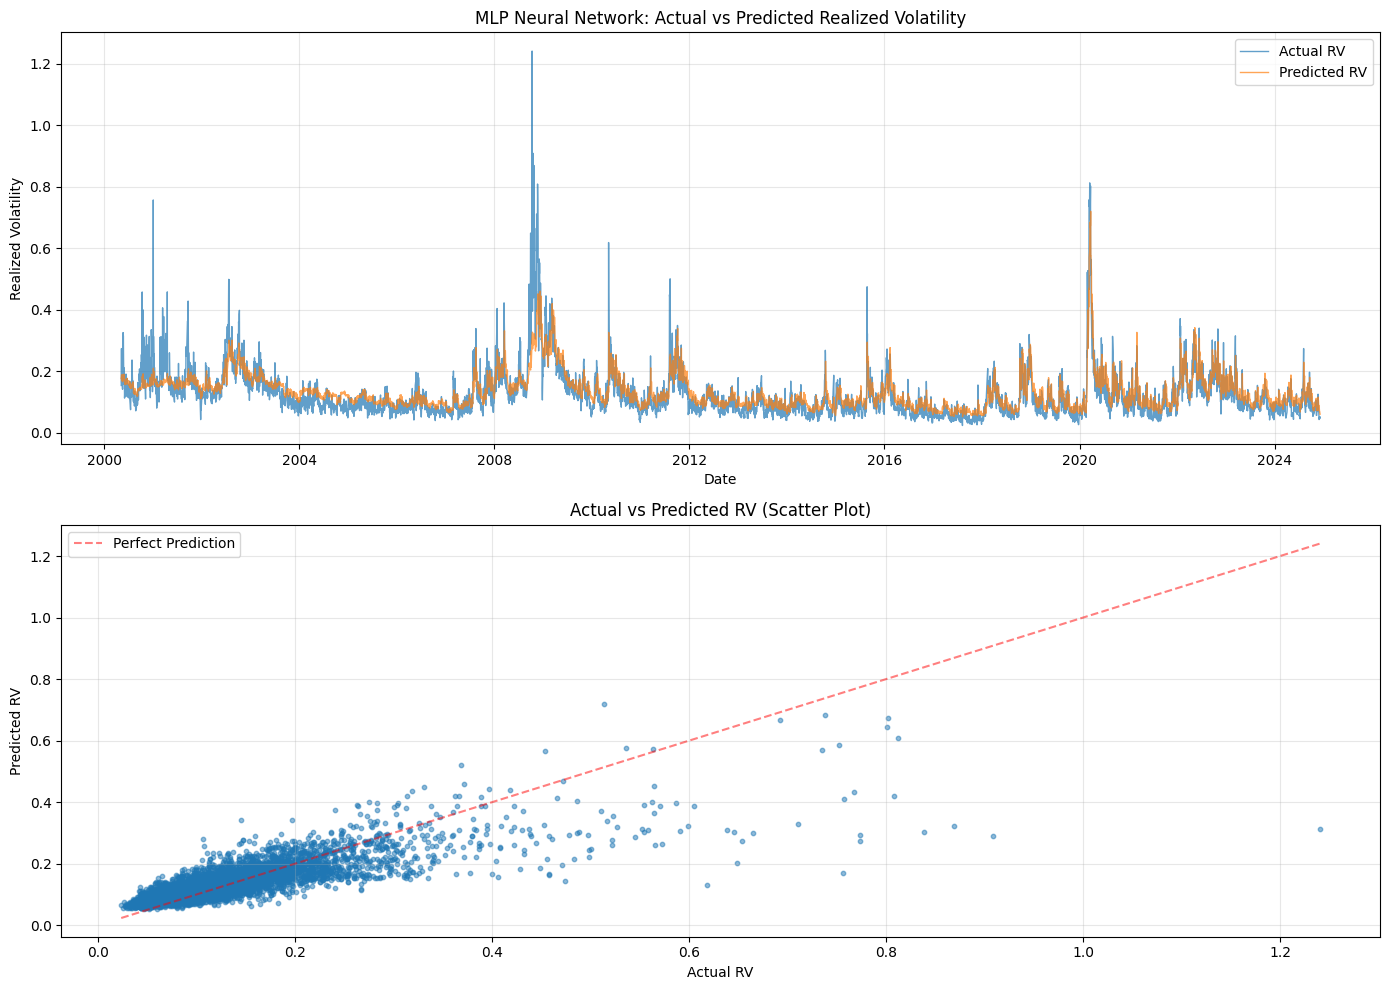

In [17]:
# ==================== LSTM Execution ====================
def main_lstm():
    """Main execution function"""
    print("="*60)
    print("LSTM NEURAL NETWORK")
    print("="*60)

    # Initialize configuration
    config = Config_LSTM()
    print(f"\nUsing device: {config.device}")

    # Load data
    print("\nLoading data...")
    rv_data = load_and_prepare_data('SPY.csv')

    # Run expanding window forecast
    results_df = expanding_window_forecast(rv_data, config)

    # Save results
    output_filename = 'lstm_rv_forecast_results.csv'
    results_df.to_csv(output_filename, index=False)
    print(f"\nResults saved to {output_filename}")

    # Print summary statistics
    print_summary_statistics(results_df)

    # Plot results
    print("\nGenerating plots...")
    plot_results(results_df)

if __name__ == "__main__":
    main_lstm()